In [63]:
import pandas as pd
import os
import glob
import re
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', palette='Set2')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [64]:
metrics_rename_dict = {
    'label#AUROC': 'AUROC',
    'Accuracy': 'Accuracy',
    'label#Precision': 'Precision',
    'label#F1': 'F1',
    'label#Recall': 'Recall',
    'label#AUPRC': 'AUPRC',
}

In [65]:
metrics_df = pd.concat([
    pd.read_csv(path).assign(**dict(zip(
        ['DEG', 'Strength', 'Extractor'],
        path.split('/')[-2].split('-')[0].split('_')
    ))).query('prefix != "a"') for path 
    in glob.glob(os.path.join('../results/supp/hardeff', '**', 'test_epoch_metrics_true.csv'))
])
metrics_df['Method'] = metrics_df['Extractor'].map({'attn': 'Ours'})
metrics_df['Test Efficiency'] = metrics_df['prefix'].map(lambda x: float(x.split('_')[-2]))
metrics_df['Efficiency'] = metrics_df['Strength'].astype(float)
metrics_df['DEG'] = metrics_df['DEG'].astype(int)
metrics_df.rename(columns=metrics_rename_dict, inplace=True)
metrics_df.reset_index(drop=True, inplace=True)


In [66]:
other_metrics_df = pd.read_parquet('data/hardeff_metrics.parquet').query('"Ours" not in Method')
metrics_df = pd.concat([metrics_df, other_metrics_df], axis=0, join='inner')

In [67]:
metrics_df[['Efficiency', 'Test Efficiency']].value_counts().unstack()

Test Efficiency,0.05,0.25,0.50,0.75,1.00
Efficiency,,,,,
0.05,75,75,75,75,75
0.25,75,75,75,75,75
0.50,75,75,75,75,75
0.75,75,75,75,75,75
1.00,75,75,75,75,75


In [68]:
palette = ["#A67EB7", "#5DA39D"]
hue_order = ['Ours', 'Mixscape']

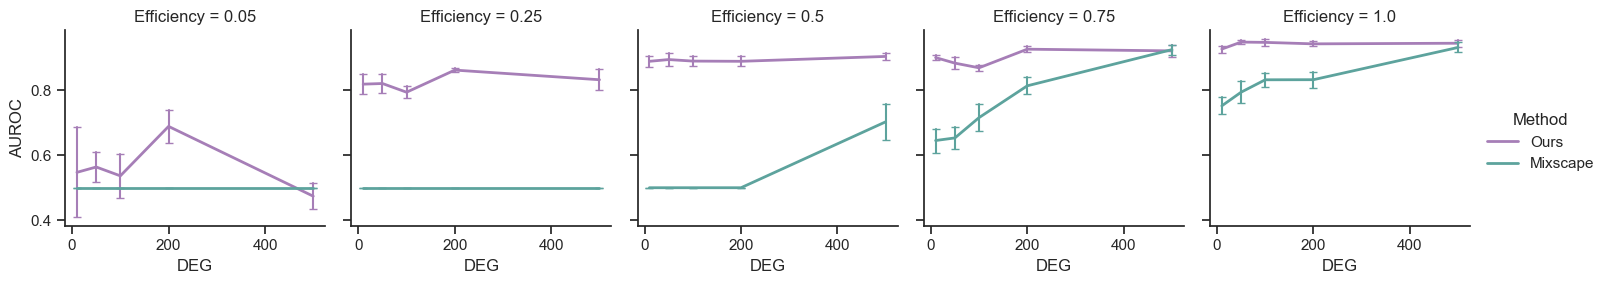

In [ ]:
g = sns.relplot(
    kind='line',
    data=metrics_df.loc[metrics_df['Test Efficiency'] == metrics_df['Efficiency']], 
    x='DEG', 
    y='AUROC', 
    hue='Method', 
    hue_order=hue_order,
    palette=palette,
    col='Efficiency',
    height=3,
    linewidth=2,
    markers=True,
    errorbar='sd',
    err_style='bars',
    err_kws={'capsize': 3},
)
g.savefig('../figures/5_simone_figure_hardeff.pdf', bbox_inches='tight')
g.figure.show()

In [70]:
(
    metrics_df
    .loc[(metrics_df['Test Efficiency'] == metrics_df['Efficiency'])]
    .query('Efficiency == 0.75 and Method == "Mixscape" and DEG == 500')
)

,Accuracy,AUPRC,AUROC,F1,Precision,Recall,DEG,Method,Test Efficiency,Efficiency
1180,0.8725,0.901257,0.931106,0.817204,0.832117,0.802817,500,Mixscape,0.75,0.75
1181,0.8725,0.904125,0.929081,0.831683,0.812903,0.851351,500,Mixscape,0.75,0.75
1182,0.8875,0.922446,0.946937,0.837545,0.859259,0.816901,500,Mixscape,0.75,0.75
1183,0.8375,0.873398,0.900231,0.771930,0.802920,0.743243,500,Mixscape,0.75,0.75
1184,0.8525,0.912984,0.930747,0.800000,0.808219,0.791946,500,Mixscape,0.75,0.75
1185,0.8125,0.870299,0.912292,0.742268,0.739726,0.744828,500,Mixscape,0.75,0.75
1186,0.8175,0.890453,0.924901,0.754209,0.746667,0.761905,500,Mixscape,0.75,0.75
1187,0.8625,0.906001,0.932666,0.801444,0.847328,0.760274,500,Mixscape,0.75,0.75
1188,0.8500,0.863774,0.903126,0.787234,0.834586,0.744966,500,Mixscape,0.75,0.75
1189,0.8650,0.902778,0.937493,0.824675,0.803797,0.846667,500,Mixscape,0.75,0.75


In [71]:
(
    metrics_df
    .loc[(metrics_df['Test Efficiency'] == metrics_df['Efficiency'])]
    .query('Efficiency == 0.75 and Method == "Ours" and DEG == 500')
)

,Accuracy,AUPRC,AUROC,F1,Precision,Recall,DEG,Method,Test Efficiency,Efficiency
150,0.8400,0.801089,0.902559,0.803681,0.770588,0.839744,500,Ours,0.75,0.75
155,0.8750,0.886212,0.942131,0.829932,0.824324,0.835616,500,Ours,0.75,0.75
160,0.8525,0.834415,0.917255,0.813880,0.786585,0.843137,500,Ours,0.75,0.75
165,0.8675,0.900135,0.939286,0.821549,0.813333,0.829932,500,Ours,0.75,0.75
170,0.8425,0.799404,0.903821,0.794788,0.762500,0.829932,500,Ours,0.75,0.75


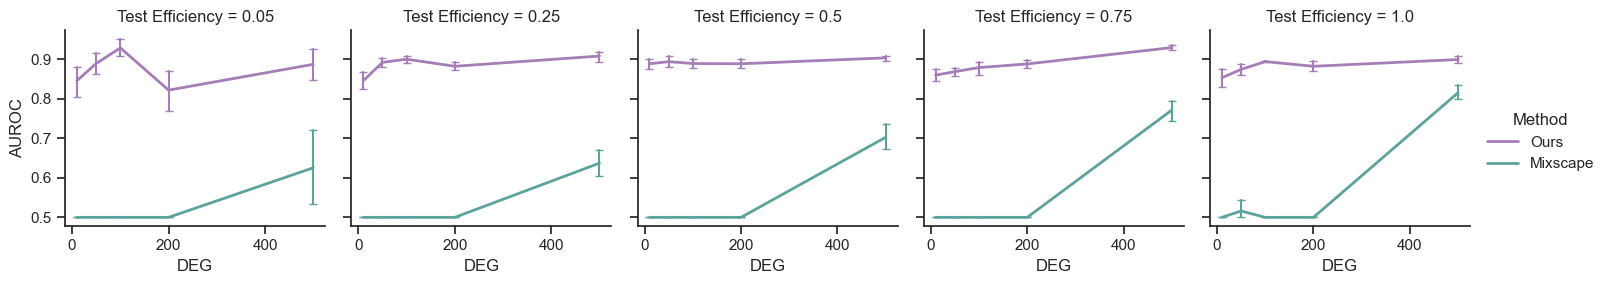

In [ ]:
g = sns.relplot(
    kind='line',
    data=metrics_df.loc[metrics_df['Efficiency'] == 0.5], 
    x='DEG', 
    y='AUROC', 
    hue='Method', 
    hue_order=hue_order,
    palette=palette,
    col='Test Efficiency',
    height=3,
    linewidth=2,
    markers=True,
    err_style='bars',
    err_kws={'capsize': 3},
)
g.savefig('../figures/5_simone_figure_hardeff_eff0.5.pdf', bbox_inches='tight')
g.figure.show()